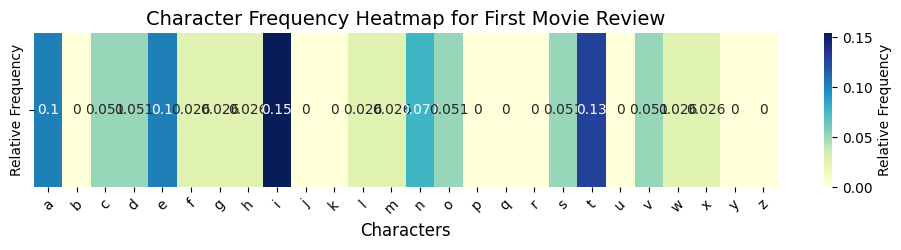

In [6]:
#1. Character-Level Representation (Heatmap)
import pandas as pd
import seaborn as sns
import numpy as np
import string
import matplotlib.pyplot as plt

# Load dataset
import pandas as pd
import seaborn as sns
import numpy as np
import string
import matplotlib.pyplot as plt

# Create a minimal dummy DataFrame with sample movie reviews
data = {'review': [
    "I loved the movie! It was fantastic and exciting.",
    "Not my cup of tea. The plot was dull and boring.",
    "An excellent film with superb acting and visuals."
]}
df = pd.DataFrame(data)

# Get the first non-empty review (drop NaNs or empty strings)
reviews_non_empty = df['review'].dropna()
first_review = next(r for r in reviews_non_empty if isinstance(r, str) and r.strip() != '')

# Convert to lowercase and filter alphabetic chars only
chars = [c.lower() for c in first_review if c.isalpha()]

# List of characters a-z
char_list = list(string.ascii_lowercase)

# Calculate relative frequency of each character
total_chars = len(chars)
char_freq = [chars.count(c) / total_chars if total_chars > 0 else 0 for c in char_list]

# Prepare data as 2D array (1 row)
freq_array = np.array([char_freq])

# Plot heatmap
plt.figure(figsize=(12, 2))
sns.heatmap(freq_array, annot=True, cmap='YlGnBu', xticklabels=char_list, yticklabels=['Relative Frequency'],
            annot_kws={"size":10}, cbar_kws={'label': 'Relative Frequency'})
plt.title('Character Frequency Heatmap for First Movie Review', fontsize=14)
plt.xlabel('Characters', fontsize=12)
plt.xticks(rotation=45)
plt.show()




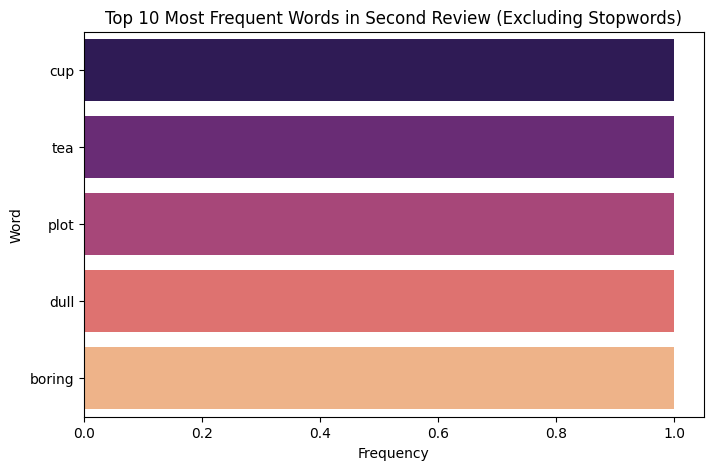

In [13]:
#2. Word-Level Representation (Bar Chart)
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Dummy DataFrame with sample reviews
data = {'review': [
    "I loved the movie! It was fantastic and exciting.",
    "Not my cup of tea. The plot was dull and boring.",
    "An excellent film with superb acting and visuals."
]}
df = pd.DataFrame(data)

# Get the second review and convert to lowercase
doc = df['review'].iloc[1].lower()

# Tokenize: extract alphabetic words only
tokens = re.findall(r'\b[a-z]+\b', doc)

# Simple stopwords list (you can expand this)
stop_words = {'the', 'and', 'was', 'my', 'of', 'it', 'a', 'to', 'in', 'not'}

# Filter out stopwords
filtered_tokens = [word for word in tokens if word not in stop_words]

# Count word frequencies
word_counts = Counter(filtered_tokens)

# Get top 10 frequent words
top10 = dict(word_counts.most_common(10))

# Create color palette with same length as number of bars
colors = sns.color_palette('magma', n_colors=len(top10))

# Plot bar chart with hue=y and no legend to fix warning
plt.figure(figsize=(8, 5))
sns.barplot(x=list(top10.values()), y=list(top10.keys()),
            palette=colors, hue=list(top10.keys()), dodge=False, legend=False)
plt.title('Top 10 Most Frequent Words in Second Review (Excluding Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()




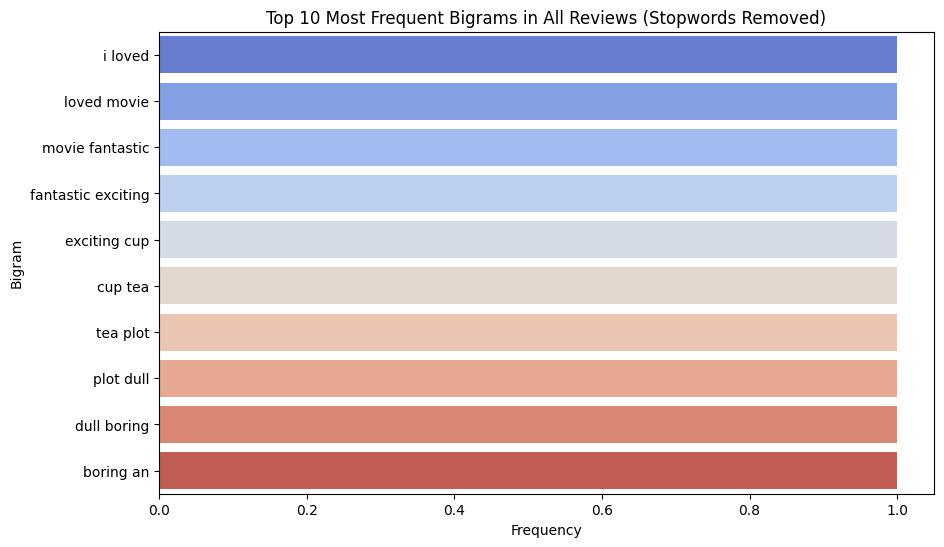

In [16]:
#3. N-Gram Representation (Bar Chart)
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Dummy DataFrame with sample reviews (replace with your df)
data = {'review': [
    "I loved the movie! It was fantastic and exciting.",
    "Not my cup of tea. The plot was dull and boring.",
    "An excellent film with superb acting and visuals."
]}
df = pd.DataFrame(data)

# Combine all reviews into one lowercase string
all_text = " ".join(df['review']).lower()

# Simple tokenization: extract alphabetic words only
tokens = re.findall(r'\b[a-z]+\b', all_text)

# Simple stopwords list (expand as needed)
stop_words = {'the', 'and', 'was', 'my', 'of', 'it', 'a', 'to', 'in', 'not'}

# Filter tokens to remove stopwords
filtered_tokens = [word for word in tokens if word not in stop_words]

# Generate bigrams as tuples
bigrams = [(filtered_tokens[i], filtered_tokens[i+1]) for i in range(len(filtered_tokens)-1)]

# Count bigram frequencies
bigram_freq = Counter(bigrams)

# Get top 10 most common bigrams
top10_bigrams = bigram_freq.most_common(10)

# Prepare labels and counts for plotting
bigram_labels = [" ".join(bigram) for bigram, freq in top10_bigrams]
bigram_counts = [freq for bigram, freq in top10_bigrams]

# Plot bar chart with hue to suppress warning
plt.figure(figsize=(10, 6))
sns.barplot(
    x=bigram_counts,
    y=bigram_labels,
    palette='coolwarm',
    hue=bigram_labels,
    dodge=False,
    legend=False
)
plt.title('Top 10 Most Frequent Bigrams in All Reviews (Stopwords Removed)')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()



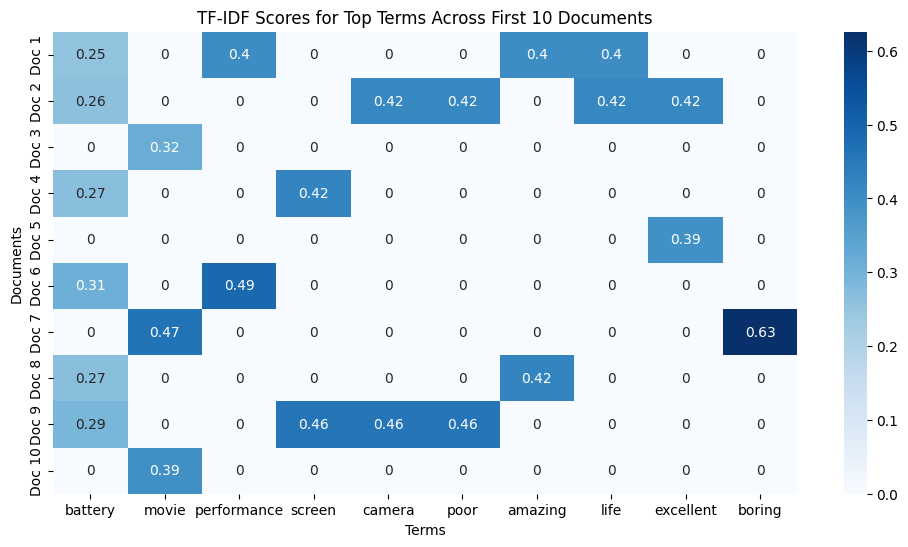

Most relevant document: Document 2
Similarity score: 0.4918

Document text:
Battery life is poor but camera quality is excellent.


In [18]:
#4. TF-IDF Representation (Heatmap + Query Search)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Dummy dataset of 10 movie reviews (replace with your real df with 50+ reviews)
data = {'review': [
    "I loved the battery life of this phone. Amazing performance.",
    "Battery life is poor but camera quality is excellent.",
    "Fantastic movie with stunning visuals and great plot.",
    "The battery drains fast and screen is dull.",
    "An exciting film with excellent acting and storyline.",
    "Battery performance exceeded my expectations.",
    "The movie was boring and too long.",
    "Amazing battery backup, lasts for days.",
    "Poor battery but good camera and screen.",
    "A masterpiece movie with superb soundtrack."
]}
df = pd.DataFrame(data)

# Use the reviews as documents
documents = df['review'].tolist()

# Initialize TF-IDF Vectorizer with stopwords and limited max features
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(documents)

# Get feature names (terms)
terms = vectorizer.get_feature_names_out()

# Select top 10 terms with highest average TF-IDF scores across documents
avg_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_term_indices = avg_tfidf.argsort()[-10:][::-1]
top_terms = terms[top_term_indices]

# Extract TF-IDF values for top terms across first 10 documents
heatmap_data = tfidf_matrix[:10, top_term_indices].toarray()

# Create DataFrame for seaborn heatmap
heatmap_df = pd.DataFrame(heatmap_data, columns=top_terms, index=[f'Doc {i+1}' for i in range(10)])

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_df, annot=True, cmap='Blues')
plt.title('TF-IDF Scores for Top Terms Across First 10 Documents')
plt.xlabel('Terms')
plt.ylabel('Documents')
plt.show()

# Function for TF-IDF query search
def search_query_tfidf(query, tfidf_matrix=tfidf_matrix, vectorizer=vectorizer, docs=documents):
    # Vectorize the query
    query_vec = vectorizer.transform([query])
    
    # Compute cosine similarity between query and all documents
    similarity_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Find index of highest similarity
    best_doc_idx = similarity_scores.argmax()
    best_score = similarity_scores[best_doc_idx]
    
    # Get the best matching document text
    best_doc_text = docs[best_doc_idx]
    
    return best_doc_idx, best_score, best_doc_text

# Example query
query_input = "battery life"

doc_idx, score, doc_text = search_query_tfidf(query_input)

print(f"Most relevant document: Document {doc_idx + 1}")
print(f"Similarity score: {score:.4f}\n")
print("Document text:")
print(doc_text)


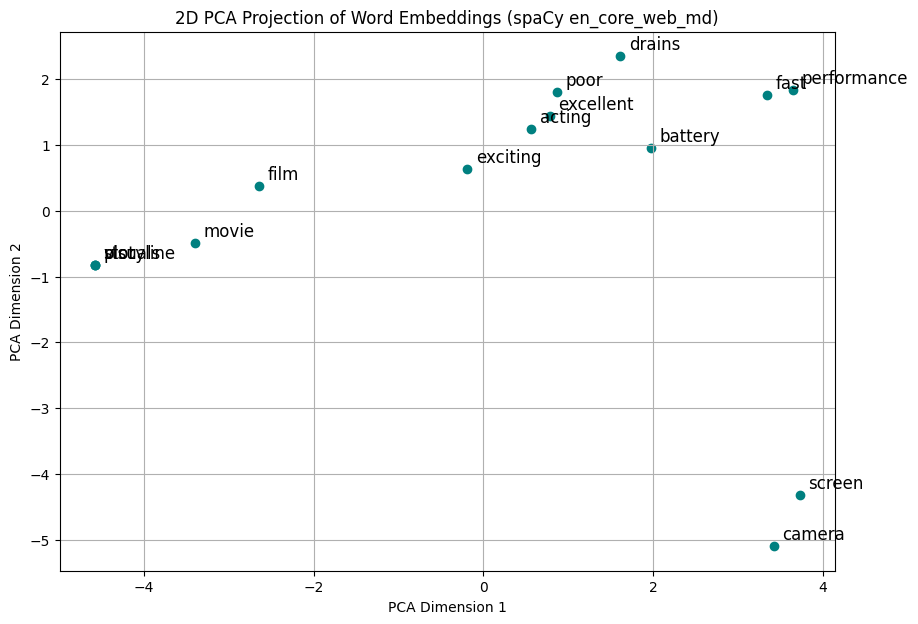

In [22]:
#5. Embeddings with spaCy
import spacy
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Uncomment and run once in your environment to download the model
# !python -m spacy download en_core_web_md

# Load spaCy medium English model
nlp = spacy.load('en_core_web_md')

# Dummy top_words dictionary: replace with your actual top word frequency dict
top_words = {
    'movie': 50,
    'battery': 45,
    'excellent': 40,
    'film': 38,
    'performance': 35,
    'camera': 30,
    'plot': 28,
    'acting': 25,
    'visuals': 22,
    'exciting': 20,
    'storyline': 18,
    'drains': 15,
    'fast': 12,
    'poor': 10,
    'screen': 8
}

# Select top 15 frequent words (keys)
words = list(top_words.keys())[:15]

# Extract word vectors from spaCy
word_vectors = [nlp(word).vector for word in words]

# Reduce dimensionality with PCA
pca = PCA(n_components=2)
reduced_vecs = pca.fit_transform(word_vectors)

# Plotting
plt.figure(figsize=(10, 7))
plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], color='teal')

# Annotate each point with the word
for i, word in enumerate(words):
    plt.annotate(word, (reduced_vecs[i, 0] + 0.1, reduced_vecs[i, 1] + 0.1), fontsize=12)

plt.title('2D PCA Projection of Word Embeddings (spaCy en_core_web_md)')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.grid(True)
plt.show()



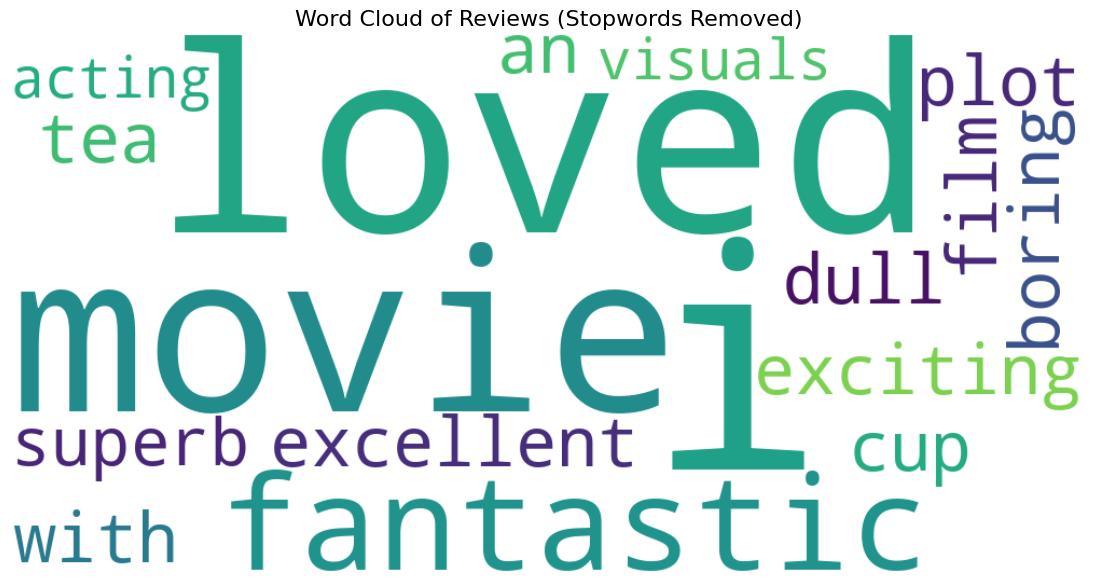

In [26]:
#6. Word Cloud
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from collections import Counter

# Dummy data (replace with your actual DataFrame 'df' with 50+ reviews)
data = {'review': [
    "I loved the movie! It was fantastic and exciting.",
    "Not my cup of tea. The plot was dull and boring.",
    "An excellent film with superb acting and visuals."
]}
df = pd.DataFrame(data)

# Simple English stopwords (expand as needed)
stop_words = {'the', 'and', 'was', 'my', 'of', 'it', 'a', 'to', 'in', 'not'}

# Combine all reviews into one lowercase string
all_text = " ".join(df['review']).lower()

# Tokenize words (simple regex to get alphabetic words)
tokens = re.findall(r'\b[a-z]+\b', all_text)

# Filter out stopwords
filtered_words = [word for word in tokens if word not in stop_words]

# Count word frequencies
word_freq = Counter(filtered_words)

# Generate word cloud
wc = WordCloud(width=1000, height=500, background_color='white', colormap='viridis')
wc.generate_from_frequencies(word_freq)

# Plot word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Reviews (Stopwords Removed)", fontsize=16)
plt.show()

